In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df1 = pd.read_csv("06-2025.csv")
df2 = pd.read_csv("07-2025.csv")
df3 = pd.read_csv("08-2025.csv")
df4 = pd.read_csv("09-2025.csv")
df5 = pd.read_csv("10-2025.csv")
df6 = pd.read_csv("11-2025.csv")
df7 = pd.read_csv("12-2025.csv")

In [7]:
df = pd.concat([df1,df2,df3,df4,df5,df6,df7], ignore_index=True)

In [9]:
df

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,80548049535,2025-06-01 16:44,Outbound,00:00:00,NaN,Kevin Nuesi
1,80547821455,2025-06-01 16:45,Outbound,00:00:00,NaN,Kevin Nuesi
2,80550594447,2025-06-01 20:15,Inbound,00:00:00,NaN,NaN
3,80566407069,2025-06-02 09:22,NaN,NaN,NaN,Robin Stoehr
4,80569306473,2025-06-02 09:52,NaN,NaN,NaN,Robin Stoehr
...,...,...,...,...,...,...
100375,100163907155,2025-12-31 18:03,Outbound,00:00:07,NaN,David Banister
100376,100161410935,2025-12-31 18:10,Outbound,00:00:02,NaN,Tyler Jury
100377,100123945791,2025-12-31 18:10,Outbound,00:00:02,NaN,Tyler Jury
100378,100158807052,2025-12-31 18:38,Outbound,00:00:07,NaN,Jerry Guadiana


In [11]:
df1 = df.drop(columns=['hs_call_outcome', 'Record ID'])

In [13]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 100380 entries, 0 to 100379
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Activity date         100380 non-null  str  
 1   Call direction        95140 non-null   str  
 2   Call duration         94927 non-null   str  
 3   Activity assigned to  94026 non-null   str  
dtypes: str(4)
memory usage: 7.2 MB


In [15]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

In [17]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 100380 entries, 0 to 100379
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Activity date         100380 non-null  datetime64[us]
 1   Call direction        95140 non-null   str           
 2   Call duration         94927 non-null   str           
 3   Activity assigned to  94026 non-null   str           
dtypes: datetime64[us](1), str(3)
memory usage: 5.6 MB


# Call Count per day

In [20]:
df2 = df1.copy()

In [22]:
df2['date'] = df2['Activity date'].dt.date

In [24]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2025-06-01 16:44:00,Outbound,00:00:00,Kevin Nuesi,2025-06-01
1,2025-06-01 16:45:00,Outbound,00:00:00,Kevin Nuesi,2025-06-01
2,2025-06-01 20:15:00,Inbound,00:00:00,NaN,2025-06-01
3,2025-06-02 09:22:00,NaN,NaN,Robin Stoehr,2025-06-02
4,2025-06-02 09:52:00,NaN,NaN,Robin Stoehr,2025-06-02


In [26]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

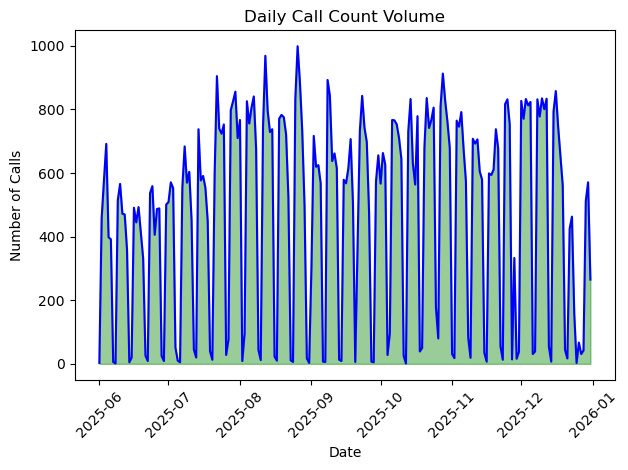

In [28]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'], color= 'blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color = 'green', alpha=0.4)

plt.title("Daily Call Count Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to
0,2025-06-01 16:44:00,Outbound,00:00:00,Kevin Nuesi
1,2025-06-01 16:45:00,Outbound,00:00:00,Kevin Nuesi
2,2025-06-01 20:15:00,Inbound,00:00:00,NaN
3,2025-06-02 09:22:00,NaN,NaN,Robin Stoehr
4,2025-06-02 09:52:00,NaN,NaN,Robin Stoehr


# Count of Call in Weekdays

In [33]:
df1['day'] = df1['Activity date'].dt.day_name()

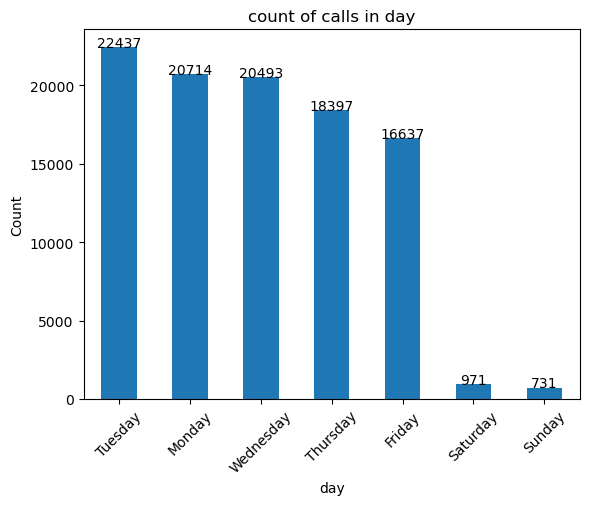

In [35]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax = day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i,v+1, str(v), ha= "center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

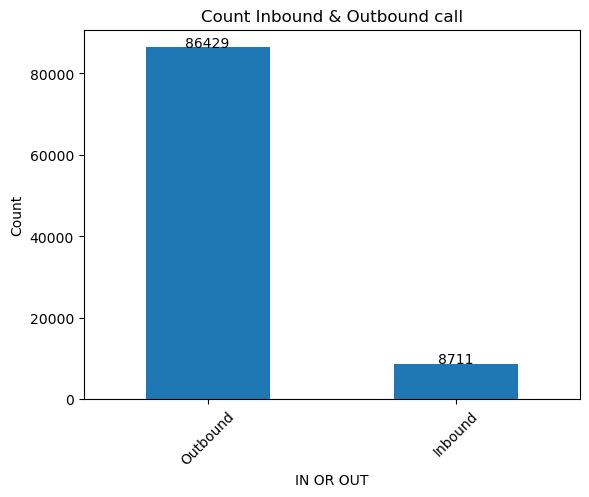

In [38]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i,v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel('IN OR OUT')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [41]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

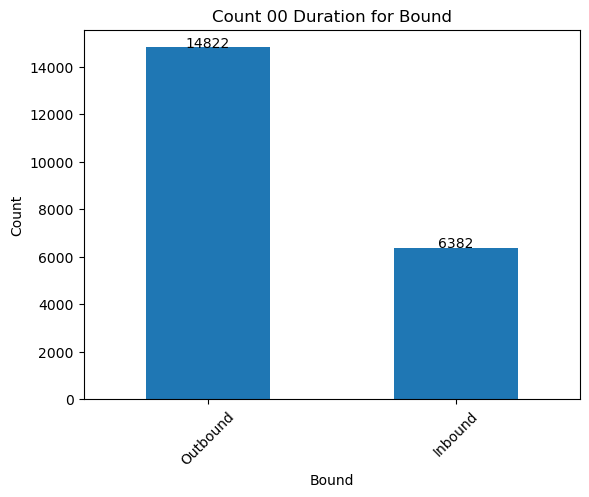

In [43]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [46]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
1964,2025-06-05 15:30:00,Outbound,NaN,Jinky Rance,Thursday
3192,2025-06-10 13:58:00,Outbound,NaN,Robin Stoehr,Tuesday
4229,2025-06-12 13:59:00,Outbound,NaN,Keith Antonio,Thursday
6424,2025-06-19 12:03:00,Inbound,NaN,Robin Stoehr,Thursday
6935,2025-06-20 14:30:00,Outbound,NaN,Christian Banks,Friday
...,...,...,...,...,...
86868,2025-12-02 12:00:00,Outbound,NaN,Cameron Dudley,Tuesday
87127,2025-12-02 16:59:00,Outbound,NaN,Oliver Martin,Tuesday
87128,2025-12-02 17:00:00,Outbound,NaN,Cameron Dudley,Tuesday
87129,2025-12-02 17:00:00,Outbound,NaN,Oliver Martin,Tuesday


In [48]:
df4 = df1.copy()

In [50]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [52]:
(df4['Call duration'] == 0).sum()

21204

In [54]:
df4['Call duration'].isnull().sum()

5453

In [56]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [58]:
df4 = df4.dropna(subset = ['Call direction'])

In [60]:
df4['Call duration'].isnull().sum()

0

In [62]:
df4['Call direction'].isnull().sum()

0

In [64]:
(df4['Call duration'] == 0).sum()

21882

In [66]:
df4.info()

<class 'pandas.DataFrame'>
Index: 95140 entries, 0 to 100379
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         95140 non-null  datetime64[us]
 1   Call direction        95140 non-null  str           
 2   Call duration         95140 non-null  float64       
 3   Activity assigned to  88879 non-null  str           
 4   day                   95140 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 6.8 MB


# Working Call Assigner

In [69]:
df1['Activity assigned to'].nunique()

50

In [71]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[           'Kevin Nuesi',                      nan,           'Robin Stoehr',
         'Cameron Dudley',        'Christian Banks',           'David Valdez',
           'Cameron Byrd',         'Boston Hoppman',          'Keith Antonio',
            'Tyler Smith',            'Jinky Rance',          'Sam Steindorf',
           'Jerome Joyce',                 'Abhi C',          'Garrett Evans',
       'Chrystel Manabat',             'Tyler Jury',            'Jon Karimov',
        'Blake Roudebush',         'David Banister',      'Brittany Digiulio',
            'Paol Guzman',        'Adonis Baybayan',          'Oliver Martin',
         'Nick Rothacher',           'Bill Goodwin',              'Juan Calo',
           'Jibran Ahmad',          'Marvin Laguna',           'Kendra Lilly',
         'Tommy Canfield',     'Jonathan Hernandez',            'Zach Drissi',
        'Taylor Shuppert',         'Andrew Stewart',        'Paulina Wegrzyn',
              'Terry Kim',       

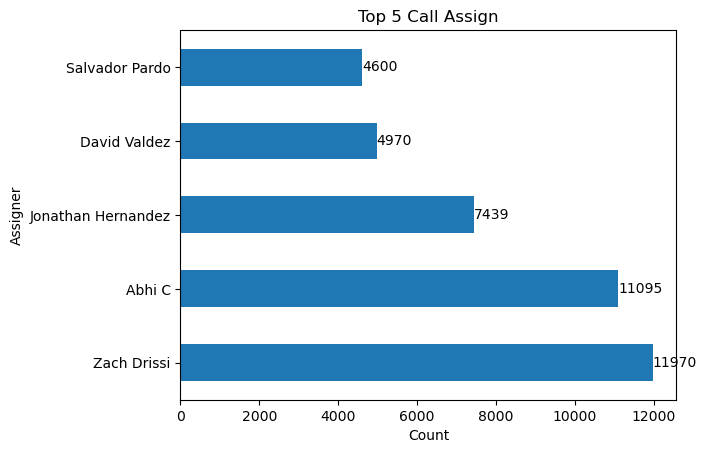

In [73]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [76]:
df4['Call duration'].max()

111.95

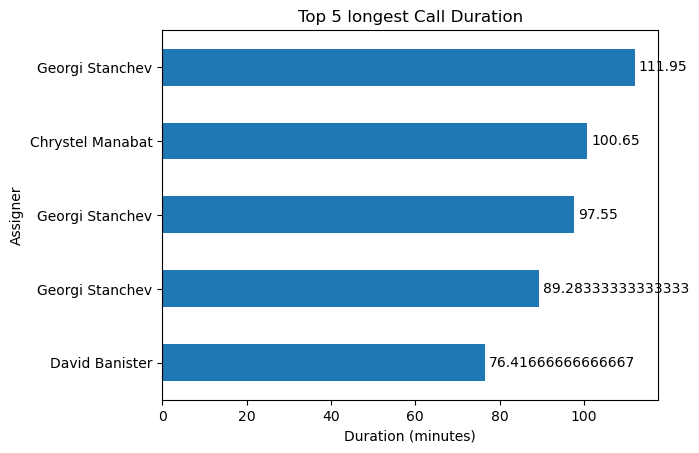

In [78]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Week days Call volume

In [81]:
df3=df1.copy()

In [83]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [85]:
df3['day'].unique()

<ArrowStringArray>
['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Length: 5, dtype: str

In [87]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

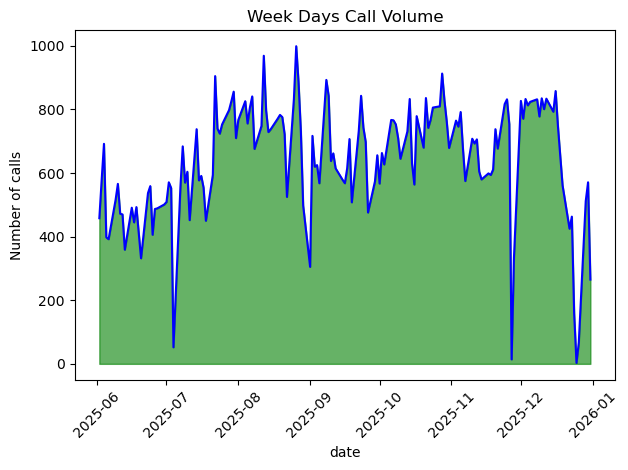

In [89]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [92]:
df5 = df4.copy()

In [94]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [96]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2025-06-01 16:44:00,Outbound,0.000000,Kevin Nuesi,Sunday
1,2025-06-01 16:45:00,Outbound,0.000000,Kevin Nuesi,Sunday
2,2025-06-01 20:15:00,Inbound,0.000000,NaN,Sunday
2521,2025-06-07 09:07:00,Outbound,0.316667,Blake Roudebush,Saturday
2522,2025-06-07 10:18:00,Inbound,0.000000,NaN,Saturday


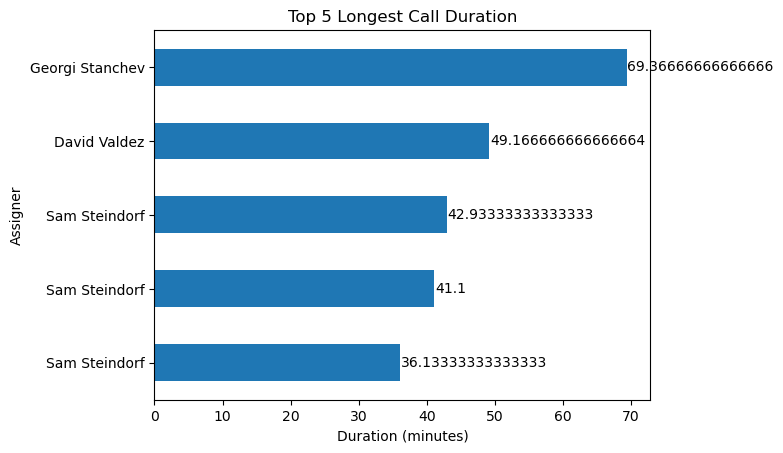

In [98]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

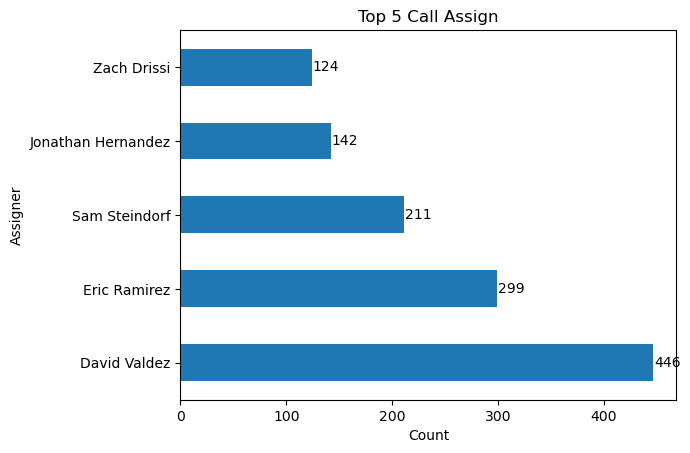

In [101]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Monthly Call Count

In [104]:
df6 = df3.copy()

In [106]:
df6['month'] = df6['Activity date'].dt.month_name()

In [108]:
df6.head()

,Activity date,Call direction,Call duration,Activity assigned to,day,month
3,2025-06-02 09:22:00,NaN,NaN,Robin Stoehr,Monday,June
4,2025-06-02 09:52:00,NaN,NaN,Robin Stoehr,Monday,June
5,2025-06-02 09:56:00,NaN,NaN,Robin Stoehr,Monday,June
6,2025-06-02 09:59:00,NaN,NaN,Robin Stoehr,Monday,June
7,2025-06-02 10:00:00,Outbound,00:00:06,Cameron Dudley,Monday,June


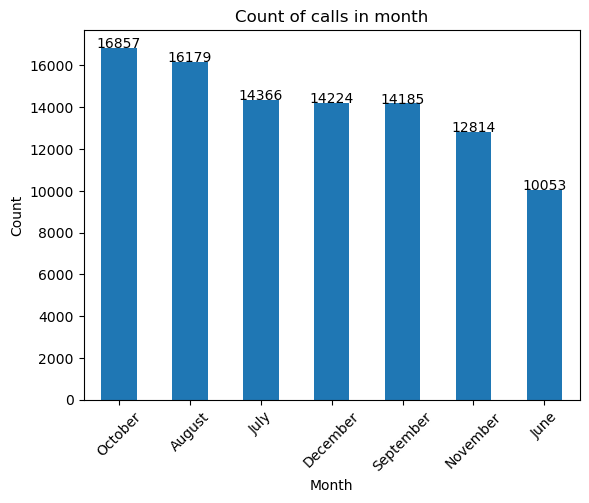

In [110]:
month_counts = df6["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls in month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# WITHOUT CALL ASSIGNER CALLS

In [113]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

In [115]:
no_assigner_calls.info()

<class 'pandas.DataFrame'>
Index: 6083 entries, 33 to 100379
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         6083 non-null   datetime64[us]
 1   Call direction        5991 non-null   str           
 2   Call duration         6082 non-null   str           
 3   Activity assigned to  0 non-null      str           
 4   day                   6083 non-null   str           
 5   month                 6083 non-null   str           
dtypes: datetime64[us](1), str(5)
memory usage: 507.3 KB


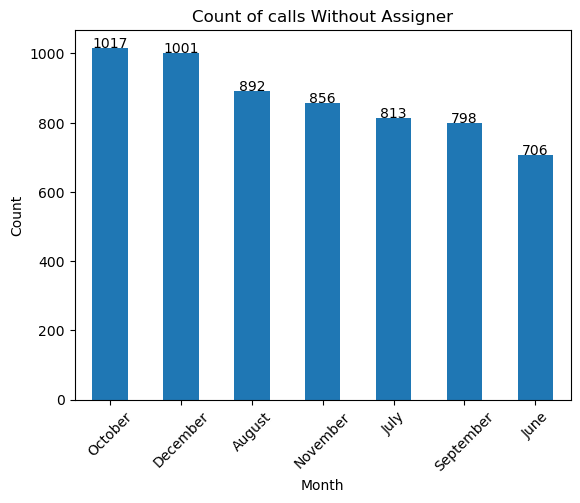

In [117]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call Date

In [120]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2025-06-01 16:44:00,Outbound,00:00:00,Kevin Nuesi,2025-06-01
1,2025-06-01 16:45:00,Outbound,00:00:00,Kevin Nuesi,2025-06-01
2,2025-06-01 20:15:00,Inbound,00:00:00,NaN,2025-06-01
3,2025-06-02 09:22:00,NaN,NaN,Robin Stoehr,2025-06-02
4,2025-06-02 09:52:00,NaN,NaN,Robin Stoehr,2025-06-02


In [122]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [124]:
top5 = daily_calls.sort_values(ascending=False).head(5)

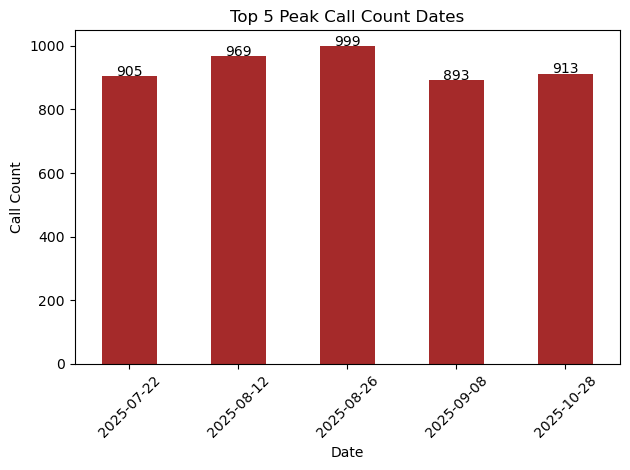

In [126]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count Dates")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()